# TimesFM Latent Visualization Demo

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/hieuduc/Downloads/AAAI')

In [2]:
import numpy as np
import torch
from transformers import TimesFmModelForPrediction

from src.data.datasets import load_dataset
from src.latents.visualize import project_umap, project_umap_3d

def resolve_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = resolve_device()
print("device =", device)


device = mps


In [3]:
# ==== Config ====
DATASET = "electricity"
MODEL_ID = "google/timesfm-2.0-500m-pytorch"
CONTEXT_LENGTH = 64
MAX_WINDOWS = 256

# Plot de de nhin hon
PLOT_2D_MAX_POINTS = 800
PLOT_3D_MAX_POINTS = 800
PLOT_3D_TRAJ_POINTS = 400

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


In [4]:
def build_windows(series, context_length=64, max_windows=256):
    n = len(series)
    if n <= context_length:
        raise ValueError("Series too short for context_length")
    starts = np.linspace(0, n - context_length - 1, num=max_windows, dtype=int)
    windows = np.stack([series[s:s+context_length] for s in starts], axis=0).astype(np.float32)

    # Normalize moi window de latent on dinh hon
    mu = windows.mean(axis=1, keepdims=True)
    sigma = windows.std(axis=1, keepdims=True) + 1e-6
    windows = (windows - mu) / sigma
    return windows

ds = load_dataset(DATASET)
series = ds.frame[ds.target_col].astype(float).to_numpy()
windows = build_windows(series, CONTEXT_LENGTH, MAX_WINDOWS)
print("dataset:", DATASET, "| rows:", len(ds.frame), "| windows:", windows.shape)


dataset: electricity | rows: 8443584 | windows: (256, 64)


In [5]:
model = TimesFmModelForPrediction.from_pretrained(MODEL_ID).to(device)
model.eval()

past_values = torch.from_numpy(windows).to(device)
freq = torch.zeros((past_values.shape[0],), dtype=torch.long, device=device)

with torch.no_grad():
    outputs = model(
        past_values=past_values,
        freq=freq,
        output_hidden_states=True,
        return_dict=True,
    )

hidden_states = outputs.hidden_states
last_hidden = hidden_states[-1].detach().float().cpu().numpy()  # [B, T, D]
embeddings = last_hidden.mean(axis=1)  # [B, D]
time_idx = np.arange(len(embeddings), dtype=float)

print("last_hidden:", last_hidden.shape, "| embeddings:", embeddings.shape)


INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.0-500m-pytorch/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/timesfm-2.0-500m-pytorch/dc2443792ce5516872b89b37cf1bc058c3bf0c10/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google/timesfm-2.0-500m-pytorch/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/813 [00:00<?, ?it/s]

/Users/hieuduc/Downloads/AAAI/.venv/lib/python3.11/site-packages/transformers/models/timesfm/modeling_timesfm.py:626: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  result = result + (torch.tensor(freq[: len(inputs)], dtype=torch.int32).reshape(-1, 1),)


last_hidden: (256, 64, 1280) | embeddings: (256, 1280)


/Users/hieuduc/Downloads/AAAI/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


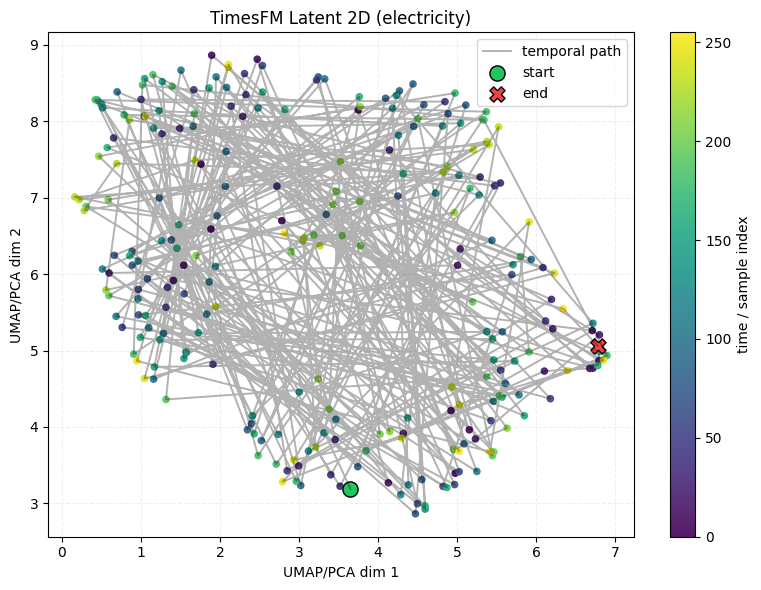

In [6]:
import matplotlib.pyplot as plt

coords2 = project_umap(embeddings, random_state=SEED)

# Giam diem de de nhin
if len(coords2) > PLOT_2D_MAX_POINTS:
    idx = np.linspace(0, len(coords2)-1, PLOT_2D_MAX_POINTS, dtype=int)
    c2 = coords2[idx]
    t2 = time_idx[idx]
else:
    c2 = coords2
    t2 = time_idx

traj_n = min(len(c2), 300)
traj_idx = np.linspace(0, len(c2)-1, max(2, traj_n), dtype=int)

plt.figure(figsize=(8, 6))
sc = plt.scatter(c2[:, 0], c2[:, 1], c=t2, cmap="viridis", s=20, alpha=0.9)
plt.plot(c2[traj_idx, 0], c2[traj_idx, 1], c="black", alpha=0.3, lw=1.4, label="temporal path")
plt.scatter(c2[0, 0], c2[0, 1], c="#22c55e", s=120, marker="o", edgecolors="black", label="start")
plt.scatter(c2[-1, 0], c2[-1, 1], c="#ef4444", s=120, marker="X", edgecolors="black", label="end")
plt.colorbar(sc, label="time / sample index")
plt.title(f"TimesFM Latent 2D ({DATASET})")
plt.xlabel("UMAP/PCA dim 1")
plt.ylabel("UMAP/PCA dim 2")
plt.grid(alpha=0.2, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
# Advanced 3D view: switch color meaning (time / volatility / outlier) -- overlap-fixed
import plotly.graph_objects as go

# Reuse coords3 from previous cell if available
try:
    coords3
except NameError:
    coords3 = project_umap_3d(embeddings, random_state=SEED)

# Feature signals for interpretation
volatility = windows.std(axis=1)
window_trend = windows[:, -1] - windows[:, 0]

# Simple outlier score in latent space (distance to centroid)
centroid = embeddings.mean(axis=0, keepdims=True)
outlier_score = np.linalg.norm(embeddings - centroid, axis=1)

# Subsample for readability
N = len(coords3)
max_points = min(PLOT_3D_MAX_POINTS, N)
idx = np.linspace(0, N - 1, max_points, dtype=int)

c3 = coords3[idx]
t_idx = time_idx[idx]
vol_idx = volatility[idx]
out_idx = outlier_score[idx]
trend_idx = window_trend[idx]

# Trajectory (coarser) and anchors
traj_n = min(PLOT_3D_TRAJ_POINTS, N)
traj_idx = np.linspace(0, N - 1, max(2, traj_n), dtype=int)
ct = coords3[traj_idx]

# For outlier-highlight mode
topk = min(12, len(c3))
outlier_top_idx = np.argsort(out_idx)[-topk:]

fig = go.Figure()

# Shared trajectory + anchors
fig.add_trace(go.Scatter3d(
    x=ct[:, 0], y=ct[:, 1], z=ct[:, 2],
    mode="lines",
    name="temporal path",
    line=dict(color="#111827", width=4),
    hovertemplate="temporal path<extra></extra>",
    visible=True,
    showlegend=True,
))
fig.add_trace(go.Scatter3d(
    x=[c3[0, 0]], y=[c3[0, 1]], z=[c3[0, 2]],
    mode="markers",
    name="start",
    marker=dict(size=8, color="#22c55e"),
    visible=True,
    showlegend=False,  # hide to avoid legend crowding
))
fig.add_trace(go.Scatter3d(
    x=[c3[-1, 0]], y=[c3[-1, 1]], z=[c3[-1, 2]],
    mode="markers",
    name="end",
    marker=dict(size=8, color="#ef4444", symbol="diamond"),
    visible=True,
    showlegend=False,  # hide to avoid legend crowding
))

# Mode 1: color by time
fig.add_trace(go.Scatter3d(
    x=c3[:, 0], y=c3[:, 1], z=c3[:, 2],
    mode="markers",
    name="windows",
    marker=dict(
        size=5,
        color=t_idx,
        colorscale="Viridis",
        opacity=0.9,
        showscale=True,
        colorbar=dict(title="time index", x=1.02, y=0.5, len=0.72, thickness=16),
    ),
    hovertemplate="time=%{marker.color:.0f}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
    visible=True,
    showlegend=True,
))

# Mode 2: color by volatility
fig.add_trace(go.Scatter3d(
    x=c3[:, 0], y=c3[:, 1], z=c3[:, 2],
    mode="markers",
    name="windows",
    marker=dict(
        size=5,
        color=vol_idx,
        colorscale="Plasma",
        opacity=0.9,
        showscale=True,
        colorbar=dict(title="volatility", x=1.02, y=0.5, len=0.72, thickness=16),
    ),
    customdata=np.stack([trend_idx], axis=1),
    hovertemplate="vol=%{marker.color:.4f}<br>trend=%{customdata[0]:.4f}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
    visible=False,
    showlegend=True,
))

# Mode 3: outlier score + highlighted top outliers
fig.add_trace(go.Scatter3d(
    x=c3[:, 0], y=c3[:, 1], z=c3[:, 2],
    mode="markers",
    name="windows",
    marker=dict(
        size=4,
        color=out_idx,
        colorscale="Magma",
        opacity=0.75,
        showscale=True,
        colorbar=dict(title="outlier score", x=1.02, y=0.5, len=0.72, thickness=16),
    ),
    hovertemplate="outlier=%{marker.color:.4f}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
    visible=False,
    showlegend=True,
))
fig.add_trace(go.Scatter3d(
    x=c3[outlier_top_idx, 0], y=c3[outlier_top_idx, 1], z=c3[outlier_top_idx, 2],
    mode="markers+text",
    name="top outliers",
    text=[f"#{i}" for i in range(topk)],
    textposition="top center",
    marker=dict(size=9, color="#f97316", line=dict(width=1, color="black")),
    hovertemplate="top outlier<extra></extra>",
    visible=False,
    showlegend=True,
))

# Visibility maps for dropdown
# traces: [path, start, end, time, vol, out, out_top]
base_on = [True, True, True]
vis_time = base_on + [True, False, False, False]
vis_vol = base_on + [False, True, False, False]
vis_out = base_on + [False, False, True, True]

fig.update_layout(
    template="plotly_white",
    title=f"TimesFM Latent 3D ({DATASET}) — Multi-view interpretation",
    scene=dict(
        aspectmode="data",
        xaxis_title="dim 1",
        yaxis_title="dim 2",
        zaxis_title="dim 3",
    ),
    # Leave room for legend and colorbar (prevents overlap)
    margin=dict(l=20, r=160, t=120, b=20),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.06,
        xanchor="left",
        x=0.0,
    ),
    width=1000,
    height=700,
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=0.01, y=1.16,
            showactive=True,
            buttons=[
                dict(
                    label="Color: time",
                    method="update",
                    args=[{"visible": vis_time}, {"title": f"TimesFM Latent 3D ({DATASET}) — color by time"}],
                ),
                dict(
                    label="Color: volatility",
                    method="update",
                    args=[{"visible": vis_vol}, {"title": f"TimesFM Latent 3D ({DATASET}) — color by volatility"}],
                ),
                dict(
                    label="Color: outlier score",
                    method="update",
                    args=[{"visible": vis_out}, {"title": f"TimesFM Latent 3D ({DATASET}) — outlier-focused"}],
                ),
            ],
        )
    ],
)

fig.show()

In [16]:
# Save file de mo ngoai notebook
out_dir = PROJECT_ROOT / "outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
html_path = out_dir / f"figure_timesfm_3d_{DATASET}_notebook.html"
fig.write_html(str(html_path), include_plotlyjs=True, full_html=True)
html_path


PosixPath('/Users/hieuduc/Downloads/AAAI/outputs/figures/figure_timesfm_3d_electricity_notebook.html')